# Tugas 2 — Menguji Kebenaran Anggota Klaster (Cluster Validation)

**Mata Kuliah:** Data Mining

## Pertanyaan
Setelah K-Means selesai, kita dapat klaster akhir + centroid akhir. **Bagaimana cara menguji bahwa tiap anggota memang benar berada di klasternya (bukan salah tempat)?**

## Dua cara menguji (dipakai di notebook ini)
1. **Uji Konsistensi — Nearest Centroid.**
   Aturannya: setiap titik harus **paling dekat ke centroid klasternya sendiri**. Kalau ada titik yang ternyata lebih dekat ke centroid klaster lain → berarti **salah tempat**. (Jika K-Means sudah konvergen, semua titik pasti lolos uji ini — artinya partisinya **sah/stabil**.)
2. **Uji Kecocokan per Titik — Silhouette.**
   Untuk tiap titik: `a` = rata-rata jarak ke teman **seklaster**; `b` = rata-rata jarak ke klaster tetangga terdekat; `s = (b − a) / max(a, b)`, rentang −1..1.
   - `s` mendekati **+1** → sangat cocok di klasternya.
   - `s` sekitar **0** → di perbatasan (atau klaster sendirian/singleton).
   - `s` **negatif** → lebih mirip klaster tetangga → **kemungkinan salah tempat**.

Kita uji pada **dua hasil**: baseline (centroid awal P1,P2) dan outlier (centroid awal P5,P9).

## Dasar Teori

Dua uji di notebook ini berdiri di atas dua landasan teori berikut.

### Teori 1 — Fungsi Objektif K-Means (dasar uji Nearest Centroid)
K-Means berusaha **meminimalkan total jarak kuadrat** setiap titik ke centroid klasternya. Ukuran ini disebut **SSE (Sum of Squared Errors)** atau **WCSS (Within-Cluster Sum of Squares)**:

$$J = \sum_{k} \sum_{x \in C_k} \lVert x - \mu_k \rVert^{2}$$

dengan $C_k$ = klaster ke-$k$ dan $\mu_k$ = centroid (rata-rata anggota) klaster $k$. Algoritma berjalan bergantian:
1. **Assign** — tiap titik dimasukkan ke centroid **TERDEKAT** (langkah inilah yang membuat $J$ turun lewat penempatan).
2. **Update** — centroid dipindah ke **rata-rata** anggotanya (langkah ini membuat $J$ turun lewat posisi centroid).

**Akibatnya:** ketika algoritma konvergen (berhenti), setiap titik **pasti berada di klaster dengan centroid terdekat** — sebab kalau ada titik yang lebih dekat ke centroid lain, $J$ masih bisa diturunkan dan algoritma belum berhenti. **Itulah dasar Uji Nearest Centroid:** memeriksa apakah tiap titik benar paling dekat ke centroidnya. Catatan penting: K-Means hanya menjamin **optimum lokal** (bergantung centroid awal), **bukan** optimum global — sehingga partisi yang "sah" belum tentu yang terbaik.

### Teori 2 — Silhouette Coefficient (Rousseeuw, 1987)
Silhouette mengukur seberapa baik sebuah titik **cocok dengan klasternya** dibanding **klaster tetangga terdekat**, dengan menggabungkan dua gagasan:
- **Kohesi** $a(i)$ = rata-rata jarak titik $i$ ke **semua titik lain di klaster yang sama** (makin kecil → klaster makin padat).
- **Separasi** $b(i)$ = rata-rata jarak titik $i$ ke **klaster tetangga terdekat** (klaster lain yang paling dekat; makin besar → makin terpisah).

$$s(i) = \frac{b(i) - a(i)}{\max\big(a(i),\, b(i)\big)}, \qquad -1 \le s(i) \le 1$$

**Cara membaca nilai $s$:**
- $s \to +1$ → titik **sangat cocok** di klasternya (jauh lebih dekat ke teman seklaster daripada ke tetangga).
- $s \approx 0$ → titik berada **di perbatasan** dua klaster.
- $s < 0$ → titik **lebih mirip klaster tetangga** → indikasi **salah tempat**.

**Patokan kualitas** (Kaufman & Rousseeuw): $0{,}71$–$1{,}00$ = struktur kuat; $0{,}51$–$0{,}70$ = wajar; $0{,}26$–$0{,}50$ = lemah; $\le 0{,}25$ = praktis tanpa struktur. Rata-rata $s$ seluruh titik dipakai menilai kualitas keseluruhan dan membantu memilih jumlah klaster $K$. Untuk **klaster berisi 1 titik (singleton)**, $s$ didefinisikan $= 0$ karena tidak ada teman seklaster sebagai pembanding.

### Teori 3 — Davies–Bouldin Index / DBI (Davies & Bouldin, 1979)
Indeks validasi internal lain untuk **uji kualitas klaster**. Idenya: klaster yang bagus harus **padat di dalam** tapi **berjauhan antar klaster**. Untuk tiap klaster:
- **Sebaran (scatter)** $S_i$ = rata-rata jarak anggota klaster $i$ ke centroid-nya (makin kecil → makin padat).
- **Pemisahan** $M_{ij}$ = jarak antar centroid klaster $i$ dan $j$.
- **Rasio kemiripan** $R_{ij} = \dfrac{S_i + S_j}{M_{ij}}$ → makin besar berarti dua klaster makin "mirip"/jelek (gemuk tapi berdekatan).
- $D_i = \max_{j \ne i} R_{ij}$ (ambil pasangan **terburuk** untuk klaster $i$).

$$DBI = \frac{1}{k} \sum_{i=1}^{k} D_i$$

**Cara baca:** makin **KECIL** DBI makin **baik** (klaster padat & saling berjauhan). Ini **kebalikan** arah Silhouette (yang makin besar makin baik). Sama seperti Silhouette, DBI juga bisa **menyesatkan jika ada klaster singleton/outlier** (scatter klaster 1-titik = 0, sehingga DBI terlihat sangat kecil/"bagus" padahal strukturnya tidak sehat).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Age=[41,47,33,29,47,40,38,42,26,47]; Inc=[19,100,57,19,253,81,56,64,18,115]
X=np.array(list(zip(Age,Inc)),float)
lbl=[f'P{i+1}' for i in range(10)]

def euclid(a,b): return np.sqrt(((np.array(a)-np.array(b))**2).sum())

def kmeans(X,c0):
    c=np.array(c0,float)
    for _ in range(50):
        labels=np.array([int(np.argmin([euclid(x,ci) for ci in c])) for x in X])
        nc=np.array([X[labels==k].mean(0) if (labels==k).any() else c[k] for k in range(2)])
        if np.allclose(nc,c): break
        c=nc
    return c,labels

cBase,labBase = kmeans(X,[X[0],X[1]])   # baseline P1,P2
cOut, labOut  = kmeans(X,[X[4],X[8]])   # outlier P5,P9
print('Baseline  -> centroid akhir:',np.round(cBase,1))
print('Outlier   -> centroid akhir:',np.round(cOut,1))

Baseline  -> centroid akhir: [[ 35.6  44.9]
 [ 47.  156. ]]
Outlier   -> centroid akhir: [[ 47.  253. ]
 [ 38.1  58.8]]


## UJI 1 — Nearest Centroid (apakah tiap titik paling dekat ke centroidnya?)

In [2]:
def uji_nearest(c, lab, nama):
    rows=[]
    for i,x in enumerate(X):
        d1,d2=euclid(x,c[0]),euclid(x,c[1])
        terdekat=int(np.argmin([d1,d2]))
        rows.append({'Titik':lbl[i],'Klaster':lab[i]+1,
                     'Jarak->C1':round(d1,1),'Jarak->C2':round(d2,1),
                     'Centroid terdekat':f'C{terdekat+1}',
                     'Status':'OK' if terdekat==lab[i] else 'SALAH TEMPAT'})
    df=pd.DataFrame(rows)
    print(f'{nama}: semua anggota benar?', (df.Status=="OK").all())
    return df

print('--- BASELINE ---')
display(uji_nearest(cBase,labBase,'Baseline'))
print('--- OUTLIER ---')
display(uji_nearest(cOut,labOut,'Outlier'))

--- BASELINE ---
Baseline: semua anggota benar? True


,Titik,Klaster,Jarak->C1,Jarak->C2,Centroid terdekat,Status
0,P1,1,26.4,137.1,C1,OK
1,P2,2,56.3,56.0,C2,OK
2,P3,1,12.4,100.0,C1,OK
3,P4,1,26.7,138.2,C1,OK
4,P5,2,208.5,97.0,C2,OK
5,P6,1,36.4,75.3,C1,OK
6,P7,1,11.4,100.4,C1,OK
7,P8,1,20.2,92.1,C1,OK
8,P9,1,28.5,139.6,C1,OK
9,P10,2,71.1,41.0,C2,OK


--- OUTLIER ---
Outlier: semua anggota benar? True


,Titik,Klaster,Jarak->C1,Jarak->C2,Centroid terdekat,Status
0,P1,2,234.1,39.9,C2,OK
1,P2,2,153.0,42.2,C2,OK
2,P3,2,196.5,5.4,C2,OK
3,P4,2,234.7,40.8,C2,OK
4,P5,1,0.0,194.4,C1,OK
5,P6,2,172.1,22.3,C2,OK
6,P7,2,197.2,2.8,C2,OK
7,P8,2,189.1,6.5,C2,OK
8,P9,2,235.9,42.5,C2,OK
9,P10,2,138.0,56.9,C2,OK


**Hasil Uji 1:** kedua skenario **lolos** (semua titik paling dekat ke centroidnya sendiri).
Ini wajar: K-Means berhenti hanya jika kondisi ini terpenuhi, jadi uji ini membuktikan **partisi sah/konsisten** — tapi **belum** memberi tahu apakah hasilnya *bermakna*. Untuk itu kita pakai Silhouette.

## UJI 2 — Silhouette per Titik (seberapa cocok tiap anggota?)

In [3]:
def silhouette_point(lab,i):
    same=[j for j in range(len(X)) if lab[j]==lab[i] and j!=i]
    if not same:
        return 0.0  # klaster sendirian (singleton) -> tidak bisa dinilai cocok/tidak
    a=np.mean([euclid(X[i],X[j]) for j in same])
    others=set(lab)-{lab[i]}
    b=min(np.mean([euclid(X[i],X[j]) for j in range(len(X)) if lab[j]==o]) for o in others)
    return (b-a)/max(a,b)

def uji_silhouette(lab,nama):
    rows=[]
    for i in range(len(X)):
        s=silhouette_point(lab,i)
        status='cocok' if s>0.5 else ('lemah' if s>0 else ('singleton' if s==0 else 'SALAH TEMPAT'))
        rows.append({'Titik':lbl[i],'Klaster':lab[i]+1,'Silhouette':round(s,3),'Status':status})
    df=pd.DataFrame(rows)
    print(f'{nama}: rata-rata silhouette = {df.Silhouette.mean():.3f}')
    return df

print('--- BASELINE ---')
display(uji_silhouette(labBase,'Baseline'))
print('--- OUTLIER ---')
display(uji_silhouette(labOut,'Outlier'))

--- BASELINE ---
Baseline: rata-rata silhouette = 0.475


,Titik,Klaster,Silhouette,Status
0,P1,1,0.745,cocok
1,P2,2,-0.327,SALAH TEMPAT
2,P3,1,0.738,cocok
3,P4,1,0.758,cocok
4,P5,2,0.302,lemah
5,P6,1,0.435,lemah
6,P7,1,0.745,cocok
7,P8,1,0.678,cocok
8,P9,1,0.749,cocok
9,P10,2,-0.069,SALAH TEMPAT


--- OUTLIER ---
Outlier: rata-rata silhouette = 0.685


,Titik,Klaster,Silhouette,Status
0,P1,2,0.793,cocok
1,P2,2,0.665,cocok
2,P3,2,0.833,cocok
3,P4,2,0.797,cocok
4,P5,1,0.000,singleton
5,P6,2,0.774,cocok
6,P7,2,0.836,cocok
7,P8,2,0.824,cocok
8,P9,2,0.791,cocok
9,P10,2,0.535,cocok


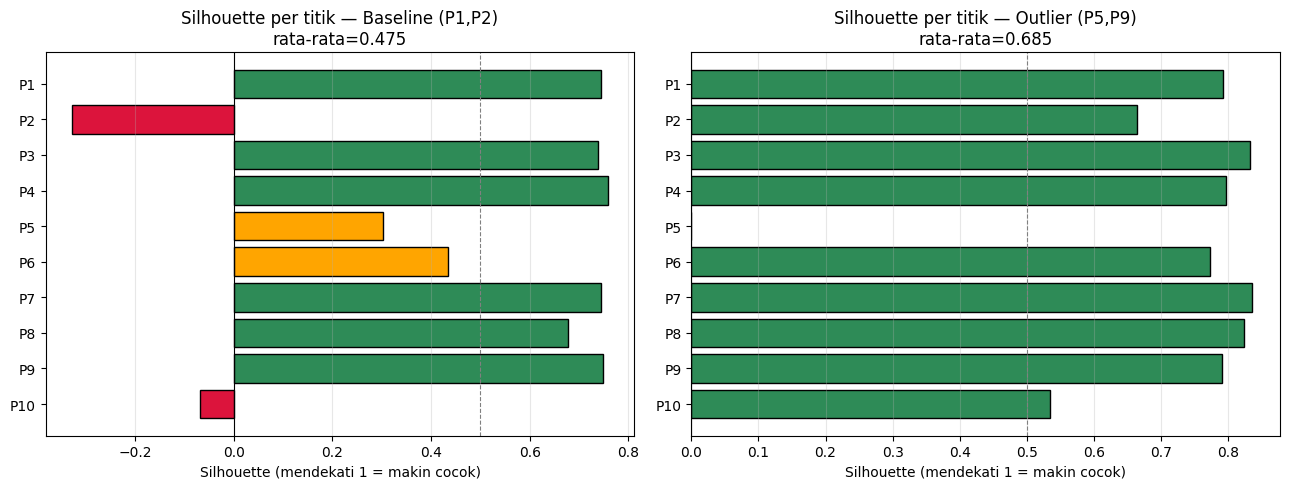

In [4]:
# Grafik silhouette per titik
fig,axes=plt.subplots(1,2,figsize=(13,5))
for ax,(lab,nama) in zip(axes,[(labBase,'Baseline (P1,P2)'),(labOut,'Outlier (P5,P9)')]):
    svals=[silhouette_point(lab,i) for i in range(len(X))]
    warna=['seagreen' if s>0.5 else ('orange' if s>0 else 'crimson') for s in svals]
    ax.barh(lbl,svals,color=warna,edgecolor='k')
    ax.axvline(0,color='k',lw=0.8); ax.axvline(0.5,color='gray',ls='--',lw=0.8)
    ax.set_title(f'Silhouette per titik — {nama}\nrata-rata={np.mean(svals):.3f}')
    ax.set_xlabel('Silhouette (mendekati 1 = makin cocok)'); ax.grid(alpha=0.3,axis='x')
    ax.invert_yaxis()
plt.tight_layout(); plt.show()

## UJI 3 — Davies–Bouldin Index (DBI)

Mengukur kualitas keseluruhan: rata-rata rasio (sebaran dalam klaster) terhadap (jarak antar centroid). **Makin kecil makin baik.**

In [5]:
def davies_bouldin(lab, c):
    k = len(c)
    S = [np.mean([euclid(X[j], c[i]) for j in range(len(X)) if lab[j] == i]) if (lab == i).any() else 0.0
         for i in range(k)]
    D = []
    for i in range(k):
        R = [(S[i] + S[j]) / euclid(c[i], c[j]) for j in range(k) if j != i]
        D.append(max(R))
    return float(np.mean(D)), S

rows = []
for nama, c, lab in [('Baseline (P1,P2)', cBase, labBase), ('Outlier (P5,P9)', cOut, labOut)]:
    dbi, S = davies_bouldin(lab, c)
    rows.append({'Skenario': nama,
                 'Scatter S1': round(S[0], 2), 'Scatter S2': round(S[1], 2),
                 'Jarak centroid M': round(euclid(c[0], c[1]), 2),
                 'Davies-Bouldin Index': round(dbi, 3)})
print('Davies-Bouldin Index — makin KECIL makin baik:')
display(pd.DataFrame(rows))

Davies-Bouldin Index — makin KECIL makin baik:


,Skenario,Scatter S1,Scatter S2,Jarak centroid M,Davies-Bouldin Index
0,"Baseline (P1,P2)",23.15,64.67,111.73,0.786
1,"Outlier (P5,P9)",0.00,28.81,194.43,0.148


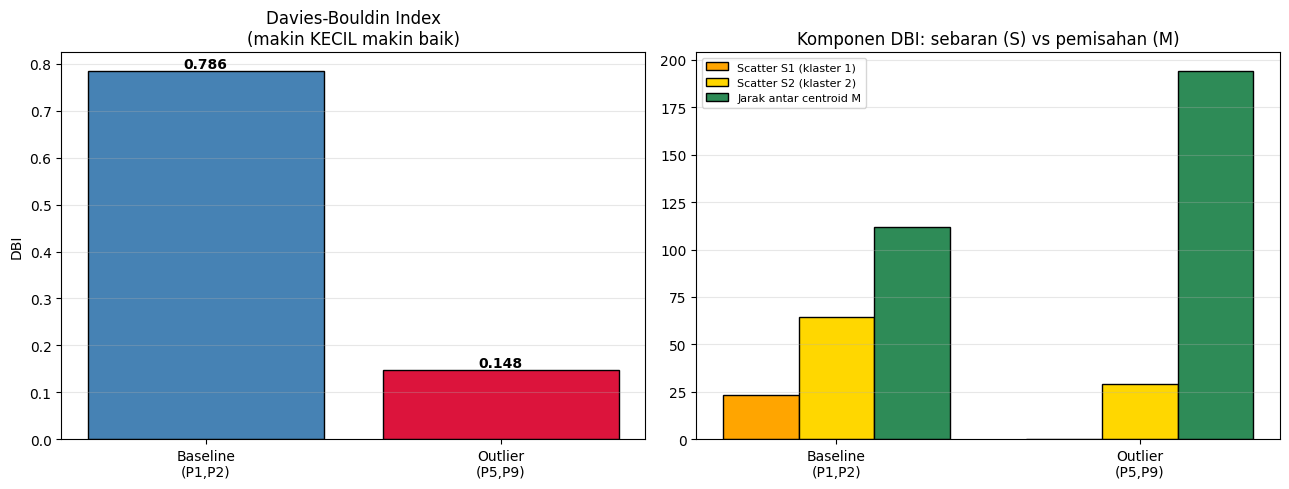

In [6]:
# Visualisasi Davies-Bouldin Index
data_dbi = []
for nama, c, lab in [('Baseline\n(P1,P2)', cBase, labBase), ('Outlier\n(P5,P9)', cOut, labOut)]:
    dbi, S = davies_bouldin(lab, c)
    data_dbi.append((nama, dbi, S, euclid(c[0], c[1])))
names = [d[0] for d in data_dbi]
dbis  = [d[1] for d in data_dbi]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel kiri: nilai DBI (makin kecil makin baik)
bars = axes[0].bar(names, dbis, color=['steelblue', 'crimson'], edgecolor='k')
for b, v in zip(bars, dbis):
    axes[0].text(b.get_x() + b.get_width()/2, v, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Davies-Bouldin Index\n(makin KECIL makin baik)')
axes[0].set_ylabel('DBI'); axes[0].grid(alpha=0.3, axis='y')

# Panel kanan: komponen pembentuk DBI -> menjelaskan kenapa outlier "tertipu"
x = np.arange(len(names)); w = 0.25
S1 = [d[2][0] for d in data_dbi]; S2 = [d[2][1] for d in data_dbi]; M = [d[3] for d in data_dbi]
axes[1].bar(x - w, S1, w, label='Scatter S1 (klaster 1)', color='orange', edgecolor='k')
axes[1].bar(x,     S2, w, label='Scatter S2 (klaster 2)', color='gold', edgecolor='k')
axes[1].bar(x + w, M,  w, label='Jarak antar centroid M', color='seagreen', edgecolor='k')
axes[1].set_xticks(x); axes[1].set_xticklabels(names)
axes[1].set_title('Komponen DBI: sebaran (S) vs pemisahan (M)')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

**Cara baca grafik DBI:**
- Panel kiri: DBI Outlier (~0.15) lebih kecil daripada Baseline (~0.79) → seolah-olah outlier "lebih bagus".
- Panel kanan menjelaskan kenapa: pada Outlier, **Scatter S1 = 0** (klaster cuma P5, jaraknya ke diri sendiri = 0) dan **jarak antar centroid M sangat besar** (~194). Rumus DBI = (S1+S2)/M jadi kecil **bukan karena klaster bagus**, tapi karena ada klaster singleton + centroid berjauhan.
- **Kesimpulan uji 3:** DBI pun bisa **menyesatkan** bila ada outlier sendirian — sama seperti Silhouette. Selalu cek bersama **ukuran klaster**.

## Kesimpulan — Cara Menguji Anggota Klaster

**Langkah menguji apakah suatu anggota benar di klasternya:**
1. **Hitung jarak titik itu ke SEMUA centroid akhir.** Jika titik paling dekat ke centroid klasternya → penempatan **konsisten** (lolos Uji 1). Kalau lebih dekat ke centroid lain → **salah tempat**.
2. **Hitung Silhouette titik itu.** `s > 0` → cocok (lebih dekat ke klaster sendiri daripada tetangga). `s < 0` → **salah tempat** (lebih mirip klaster tetangga). `s ≈ 0` → di perbatasan atau klaster sendirian.

**Temuan dari dua skenario (penting & jadi pelajaran):**
- **Uji 1** lolos di kedua skenario → membuktikan keduanya partisi yang **sah** secara K-Means.
- **Uji 2 (Silhouette)** memperlihatkan kualitas sebenarnya:
  - **Baseline (7:3):** beberapa titik (mis. P2, P10) bernilai negatif/kecil → di perbatasan antara dua klaster. Rata-rata ≈ **0.48**.
  - **Outlier (1:9):** rata-rata ≈ **0.69** (terlihat "lebih tinggi"), **TAPI** P5 bernilai **0** karena **klaster sendirian (singleton)** — tidak ada teman seklaster untuk dibandingkan, jadi kecocokannya **tak bisa dinilai**. Nilai rata-rata yang tinggi di sini **menyesatkan**, karena hanya mencerminkan 9 titik yang rapat, bukan struktur yang bermakna.

**Inti jawaban:**
- Untuk menguji satu anggota: bandingkan **jaraknya ke tiap centroid** (Uji 1) dan lihat **silhouette-nya** (Uji 2).
- **Jangan menilai hanya dari satu angka.** Silhouette rata-rata yang tinggi belum tentu bagus bila ada **klaster singleton/outlier**. Selalu cek **per titik** + perhatikan **ukuran klaster** (klaster berisi 1 outlier adalah tanda hasil yang tidak sehat).

**Tambahan — hasil Davies–Bouldin Index (DBI):** Baseline ≈ **0.79**, Outlier ≈ **0.15**. Sekilas outlier "lebih baik" (DBI lebih kecil), **TETAPI** itu lagi-lagi karena klaster singleton P5 punya sebaran (scatter) = 0 dan centroid-nya jauh — jadi DBI pun **tertipu** sama seperti Silhouette. **Pelajaran: jangan menilai dari satu indeks; cek juga ukuran klaster (klaster berisi 1 outlier = tanda hasil tidak sehat).**